## Problem 3: Satellite Geometry [14 points + 3 bonus]

**Goal of this problem**: Students will learn about Dilution of Precision (DOP) in nominal and adverse settings.

Recall from Lecture 4 that $(G^\top G)^{-1}$ tells us how the user-satellite geometry affects our Dilution of Precision and state uncertainty, where $G$ is the geometry matrix.  
In class, we created the $G$ matrix with unit direction vectors in the ECEF (Earth-Centered-Earth-Fixed) reference frame; however, it is often more intuitive and practical to understand our state uncertainty in our local reference frame, i.e., ENU frame (East-North-Up).

Thus, let us define a new geometry matrix $\tilde{G}$ as:

$$
\tilde{G} =
\begin{bmatrix}
\left(-\mathbf{1}_{\text{ENU}}^{(1)}\right)^\top & 1 \\
\left(-\mathbf{1}_{\text{ENU}}^{(2)}\right)^\top & 1 \\
\vdots & \vdots \\
\left(-\mathbf{1}_{\text{ENU}}^{(N)}\right)^\top & 1
\end{bmatrix}
$$

Notice, this matrix is almost identical to the one we derived in class, but where we use a unit direction vector that is defined in our local, ENU reference frame (denoted by $\mathbf{1}_{\text{ENU}}^{(1)}$).  

Let us define our local DOP matrix as:

$$
\tilde{H} = (\tilde{G}^\top \tilde{G})^{-1},
$$

which corresponds to the following $\mathbb{R}^{4\times 4}$ matrix:

$$
\tilde{H} =
\begin{bmatrix}
\text{EDOP}^2 & \cdot & \cdot & \cdot \\
\cdot & \text{NDOP}^2 & \cdot & \cdot \\
\cdot & \cdot & \text{VDOP}^2 & \cdot \\
\cdot & \cdot & \cdot & \text{TDOP}^2
\end{bmatrix},
$$

where EDOP is our East DOP, NDOP is our North DOP, VDOP is our Vertical DOP (i.e., up direction), and TDOP is the same as defined in lecture 4, i.e., our Time DOP.  

Each of these terms refers to how much the satellite geometry *dilutes* (or degrades) our precision in the user position and time when the DOP value $>1$ or improves our precision when the DOP value $<1$.  
For example, a high EDOP and low NDOP mean that we have worse precision in the East direction and better precision in the North direction.  

The off-diagonal terms are generally not zero, but will generally be smaller in magnitude[1].

With this matrix $\tilde{H}$, we additionally get the following definitions of Horizontal DOP (HDOP) and Position DOP (PDOP):

$$
\text{HDOP} = \sqrt{ \text{EDOP}^2 + \text{NDOP}^2 }, \\
\text{PDOP} = \sqrt{ \text{EDOP}^2 + \text{NDOP}^2 + \text{VDOP}^2 }.
$$

[1]: By construction, $\tilde{H}$ is a positive semi-definite matrix and is positive definite in practice.

In [ ]:
import numpy as np
import pandas as pd
from google.colab import drive
import os
from dataclasses import dataclass

if not os.path.ismount("/content/drive"):
    print("Mounting Google Drive...")
    drive.mount("/content/drive")
else:
    print("Google Drive already mounted")
gdrive = True
notebooks_dir = os.path.join("/content/drive/MyDrive/AA 272 - GPS Class/HW2")

Mounting Google Drive...
Mounted at /content/drive


### 3.1 [2 points]

Create a function called `get_unit_vector(az, el)`, which takes in a satellite's azimuth and elevation angle in degrees, `az` and `el`, respectively, and outputs the 3-dimensional unit vector which represents the "look" direction to that satellite in the local, ENU reference frame.  
  If you are using GNSS Lib Py, the function can be `get_unit_vector(navdata)`.

*Hint:* This [reference document](https://x-lumin.com/wp-content/uploads/2020/09/Coordinate_Transforms.pdf) or chapter 6.1.2 of the GPS textbook might help in defining the unit direction vector in the local frame, given an azimuth and elevation angle.  
Take a look at the section on *local horizon coordinates* in the linked file.  

*Hint:* A unit vector (also, the output of your function!) has magnitude 1.

***ANSWER***

In [ ]:
from numpy.linalg import norm
import numpy as np

In [ ]:
RAD_TO_DEG = 180.0/np.pi
DEG_TO_RAD = np.pi/180.0

In [ ]:
# I used my naming convention but wrapped it
def topo_horizon_to_ENU(azimuth, elevation, use_degree=False):
  azimuth = azimuth * DEG_TO_RAD if use_degree else azimuth
  elevation = elevation * DEG_TO_RAD if use_degree else elevation

  east = np.sin(azimuth) * np.cos(elevation)
  north = np.cos(azimuth) * np.cos(elevation)
  up = np.sin(elevation)

  r_enu = np.array([east, north, up])

  # Should be unit vector, but normalizing just in case
  r_norm = norm(r_enu)

  r_enu = r_enu / r_norm

  return r_enu

def get_unit_vector(az, el, use_degree = True):
  return topo_horizon_to_ENU(az, el, use_degree)

Using the skyplots from homework 1, recall that the GPS satellites can only appear in the blue subset of the skyplot in the figure below.

These satellite locations, along with their elevation and azimuth are included on Canvas as a CSV file named `hw2_p3_az_el_data.csv`

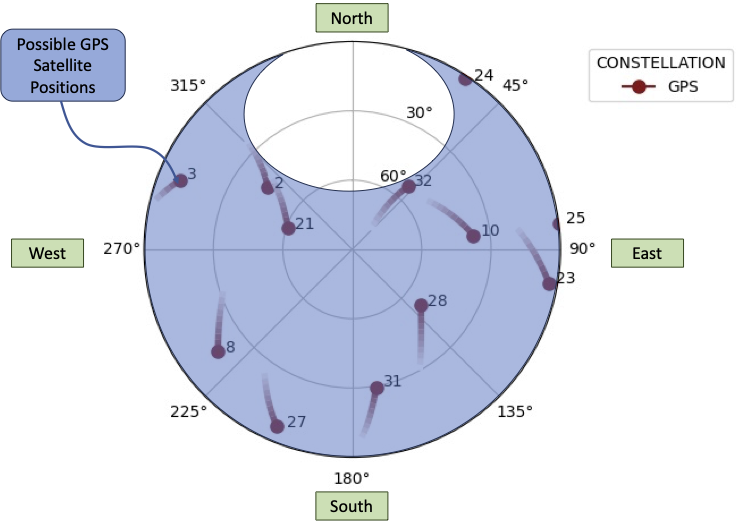

In [ ]:
from IPython.display import Image, display

display(Image(f"{notebooks_dir}/images/HW2_P4_DOP_OpenSky.png", width=600))

### 3.2 [1 point]
Using your function, `get_unit_vector`, what is the ENU direction vector to **GPS satellite 27**? (Azimuth: $203.0^{\circ}$, Elevation: $6.7^{\circ}$) You can intuitively check your answer by referencing the skyplot.

***ANSWER***

In [ ]:
satellite_data = pd.read_csv(f"{notebooks_dir}/data/hw2_p3_az_el_data.csv")
satellite_27 = satellite_data[satellite_data['sv_id'] == 27]

In [ ]:
azimuth = satellite_27['az_sv_deg'].iloc[0]
elevation = satellite_27['el_sv_deg'].iloc[0]

print(f"Azimuth: {float(azimuth)}deg")
print(f"Elevation: {float(elevation)}deg")

print(f"ENU direction vector: {get_unit_vector(azimuth, elevation)}")

Azimuth: 203.0083505975292deg
Elevation: 6.707822482097567deg
ENU direction vector: [-0.3881897  -0.91414716  0.11680633]



[Replace with your answer]

### 3.3 [2 points]
Create a function called `compute_dop_matrix(az_arr, el_arr)` (or if using GNSS Lib Py, `compute_dop_matrix(navdata)`) which takes in an array of satellite azimuth and elevation angles in degrees, `az_arr` and `el_arr`, respectively, and calls your `get_unit_vector` function from part (3.1) to output the DOP matrix $\mathbf{\tilde{H}}$ in the ENU frame.

Plot the resulting DOP matrix for the open sky condition as a heatmap.

*Hint:* Use the following function for heatmap generation.

In [ ]:
import matplotlib.pyplot as plt

def plot_dop_matrix(H, cmap='RdBu_r', vmin=-20, vmax=20,
                    symmetric_color=True, label_nums=True):
    if symmetric_color:
        if (vmin is not None) or (vmax is not None):
            if not np.isclose(np.abs(vmin), np.abs(vmax)):
                raise ValueError(f"Cannot force symmetric color since vmin ({vmin}) is not of equal magnitude to vmax ({vmax})")
        else:
            # Estimate the vmin and vmax from values
            vmax = np.max(np.abs(H))
            vmin = - vmax

    # Plot the matrix as an image
    plt.imshow(H, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar()

    # Set the tick marks
    ticks = [0, 1, 2, 3]
    tick_labels = ["East", "North", "Up", "Time"]
    plt.xticks(ticks, tick_labels)
    plt.yticks(ticks, tick_labels)

    # Label the numbers
    if label_nums:
        for (j,i), label in np.ndenumerate(H):
            plt.text(i,j, f"{label:.3f}", ha='center', va='center')

***ANSWER***

In [ ]:
def compute_dop_matrix(az_arr, el_arr, use_degree=True):
  """Both arrays are python lists or numpy vectors (1D)"""

  num_satellites = len(az_arr)

  G = np.ones((num_satellites, 4))
  for i, (az, el) in enumerate(zip(az_arr, el_arr)):
    enu_vector = get_unit_vector(az, el, use_degree)

    G[i, 0:3] = - enu_vector.reshape((1,3))

  return dsv


In [ ]:
azimuths = satellite_data['az_sv_deg']
elevations = satellite_data['el_sv_deg']

H = compute_dop_matrix(azimuths, elevations, use_degree=True)

print(f"H matrix:\n{H}")

H matrix:
[[ 0.20097502 -0.01913473  0.05142934  0.03780211]
 [-0.01913473  0.43919681 -0.19899284 -0.14190813]
 [ 0.05142934 -0.19899284  1.03224535  0.48714849]
 [ 0.03780211 -0.14190813  0.48714849  0.32733601]]


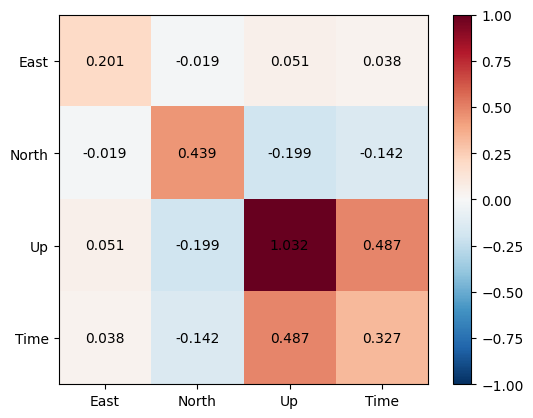

In [ ]:
plot_dop_matrix(H, vmin=-1, vmax=1)

### 3.4 [2 points]
Create a function called `compute_pdop(H)`, which uses the output of your `compute_dop_matrix` function and computes the **PDOP** for the provided satellites. Check that the PDOP of the provided satellites is **1.29**.

***ANSWER***

In [ ]:
def compute_pdop(H):
  return np.sqrt(H[0,0] + H[1,1] + H[2,2])

Now imagine that there were buildings around the receiver, forming an urban canyon, as shown below

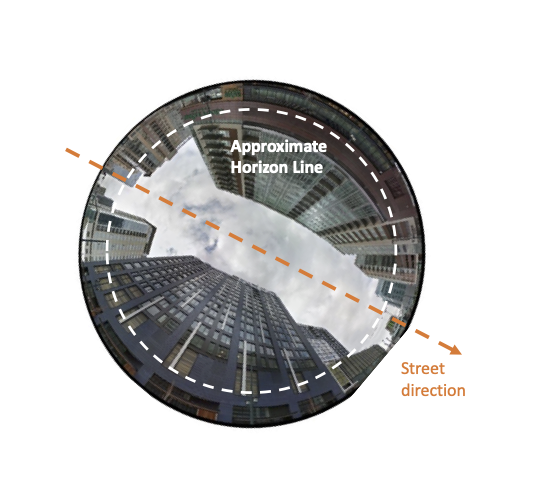

In [ ]:
from IPython.display import Image, display

display(Image(f"{notebooks_dir}/images/SalesforceDataImageAA272.png", width=400))

These buildings will block the satellite signals.
If a signal does reach the receiver, it will have bounced on other buildings before reaching the receiver.
So, the measured pseudorange will have large errors (The technical term is ``non-line-of-sight bias`` or ``NLOS bias``)
Suppose we can correctly remove all the signals that are blocked or degraded from the buildings.
The only remaining visible GPS satellites are 2, 3, 21, 28 (left to right) in the figure below.

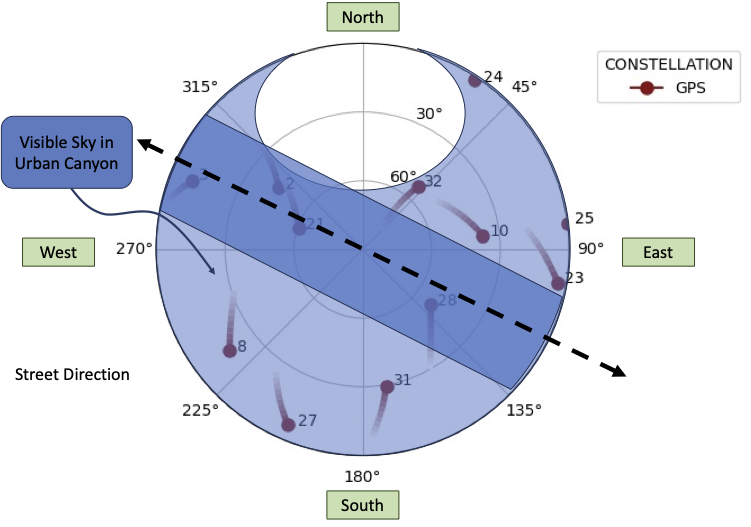

In [ ]:
from IPython.display import Image, display

display(Image(f"{notebooks_dir}/images/HW2_P4_DOP_UrbanCanyon.png", width=600))

H matrix:
[[16.6282074  22.82428202 -6.8016688  -7.21293016]
 [22.82428202 34.41260325 -7.66052989 -8.40886355]
 [-6.8016688  -7.66052989  7.03771467  5.87671075]
 [-7.21293016 -8.40886355  5.87671075  5.43863782]]


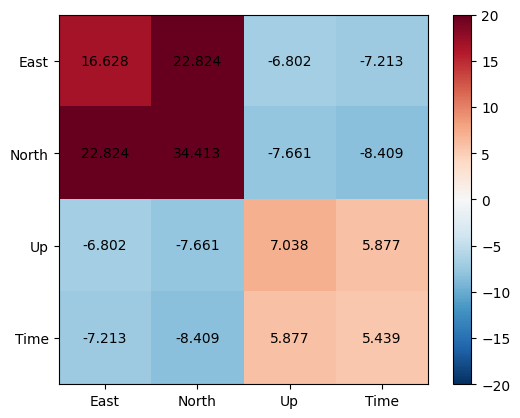

In [ ]:
satellites_in_view = satellite_data[satellite_data['sv_id'].isin([2,3,21,28])]

azimuths = satellites_in_view['az_sv_deg']
elevations = satellites_in_view['el_sv_deg']

H = compute_dop_matrix(azimuths, elevations, use_degree=True)

print(f"H matrix:\n{H}")

plot_dop_matrix(H, vmin=-20, vmax=20)

The North/South dilution of precision is very high, and the East/West is fairly high as well.

### 3.5 [4 points]
Using your function, `compute_dop_matrix(az_arr, el_arr)`, output the **new DOP matrix** with only the four available satellites visible from within the urban canyon. Briefly comment on the difference you see in the DOP matrix. Specifically, what has changed in the diagonal components (i.e., EDOP, NDOP, VDOP, and TDOP) and the off-diagonal components?

***ANSWER***


[Replace with your answer]


*Deliverable: The new DOP matrix $\mathbf{\tilde{H}}$ (as a heatmap plot) and brief (roughly 1-2 sentences) comments to the questions.*

### 3.6 [3 points]
Using your function, `compute_pdop(H)`, what is the **PDOP** within the urban canyon. Is it higher or lower than before? Why?

***ANSWER***

In [ ]:
print(f"Urban Canyon PDOP: {compute_pdop(H)}")

Urban Canyon PDOP: 7.620926801987277


As explained in 3.5, the East/West and North/South dilutions of precision are very large compared to the full-sky view. This is likely due to urban canyon being fairly small and only in a thin line. Thus, the data is not as precise as it would be with a wide variety of locations in the sky.

---
There is an ongoing effort to develop a receiver that can track weak GPS signals near the Moon (Example: LuGRE Mission). Figure below shows the skyplot of the GPS satellites at different locations on the Moon, where the GPS satellite directions are clustered in the lunar user's sky. In this bonus problem, we will think about the challenges of using GPS signals on the Moon by computing the DOP values.

We are provided with four CSV files on Canvas for the following lunar surface locations:

1. GruithuisenDomes: `hw2_p3_bonus_Shackleton.csv`
2. MariusHills: `hw2_p3_bonus_MariusHills.csv`
3. RimaBode: `hw2_p3_bonus_RimaBode.csv`
4. Shackleton: `hw2_p3_bonus_GruithuisenDomes.csv`

Each file contains the azimuth and elevation of the GPS satellites that are visible from the 4 locations on the lunar surface shown in the figure below (These values were computed using the GPS satellite positions and lunar position on August 1st, 2022)

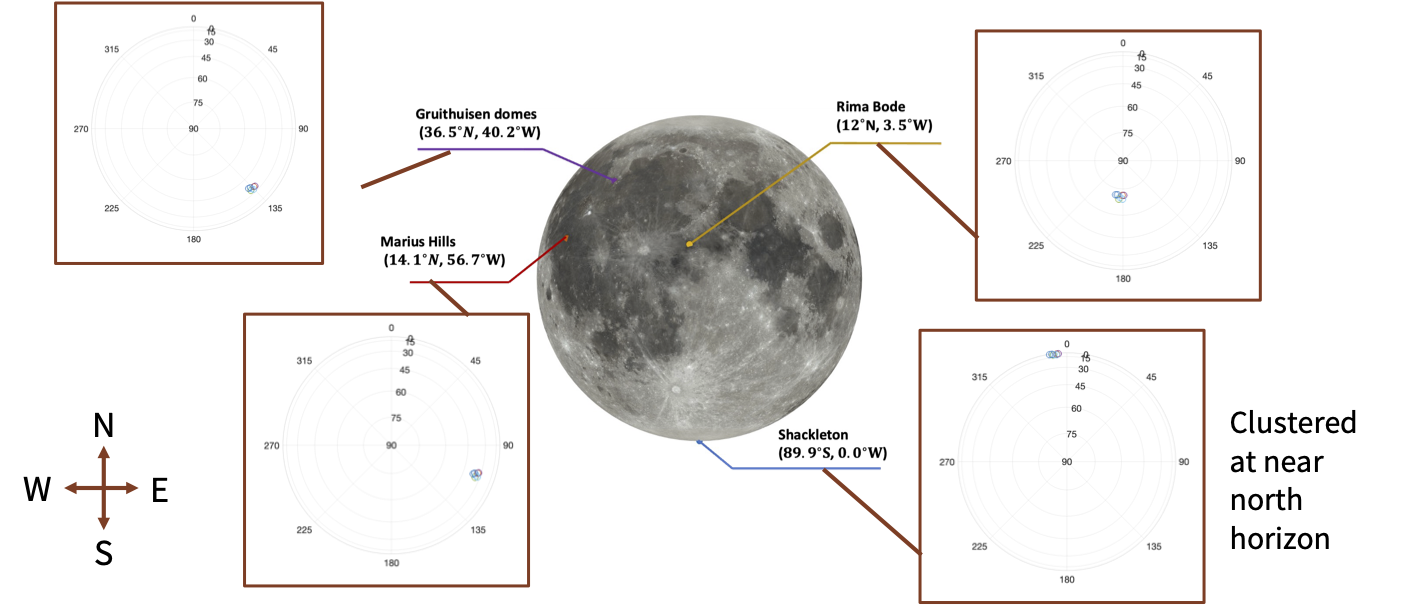

In [ ]:
from IPython.display import Image, display

display(Image(f"{notebooks_dir}/images/LunarSkyPlots.png", width=800))

*Hint:* The column labels of the azimuth and elevation are the same as the data we provided for Problem 3. If you are using gnsslibpy, you can load the csv files as `navdata` using the following function. Then, you can use the same function you implemented in Problem 3 to compute the DOP matrices.

```
import gnss_lib_py as glp

data_sh = glp.NavData(csv_path="hw2_p3_bonus_Shackleton.csv")
data_mh = glp.NavData(csv_path="hw2_p3_bonus_MariusHills.csv")
data_rb = glp.NavData(csv_path="hw2_p3_bonus_RimaBode.csv")
data_gd = glp.NavData(csv_path="hw2_p3_bonus_GruithuisenDomes.csv")
```

### 3.7 Bonus [1 point]
Using your function, `compute_dop_matrix(az_arr, el_arr)` and `compute_pdop(H)`, output the DOP matrix and PDOP value for each of the surface locations. At which surface location do you observe the **largest (worst) PDOP**? At what surface location do you see the **smallest (best) PDOP**?

***ANSWER***

In [ ]:
data_sh = pd.read_csv(f"{notebooks_dir}/data/hw2_p3_bonus_Shackleton.csv")
data_mh = pd.read_csv(f"{notebooks_dir}/data/hw2_p3_bonus_MariusHills.csv")
data_rb = pd.read_csv(f"{notebooks_dir}/data/hw2_p3_bonus_RimaBode.csv")
data_gd = pd.read_csv(f"{notebooks_dir}/data/hw2_p3_bonus_GruithuisenDomes.csv")

data_sh_az = data_sh['az_sv_deg']
data_sh_el = data_sh['el_sv_deg']
data_mh_az = data_mh['az_sv_deg']
data_mh_el = data_mh['el_sv_deg']
data_rb_az = data_rb['az_sv_deg']
data_rb_el = data_rb['el_sv_deg']
data_gd_az = data_gd['az_sv_deg']
data_gd_el = data_gd['el_sv_deg']


PDOP: 1372.145690066752


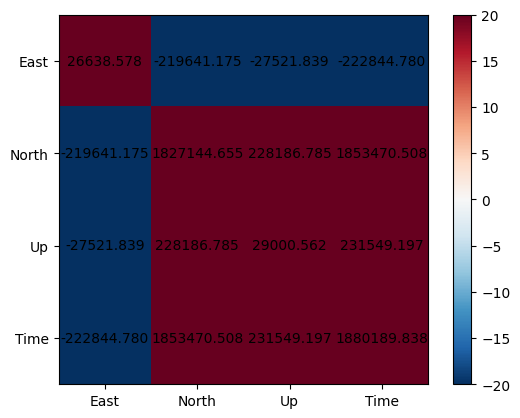

In [ ]:
H_sh = compute_dop_matrix(data_sh_az, data_sh_el, use_degree=True)
plot_dop_matrix(H_sh, vmin=-20, vmax=20)
print(f"PDOP: {compute_pdop(H_sh)}")

PDOP: 1364.807647794641


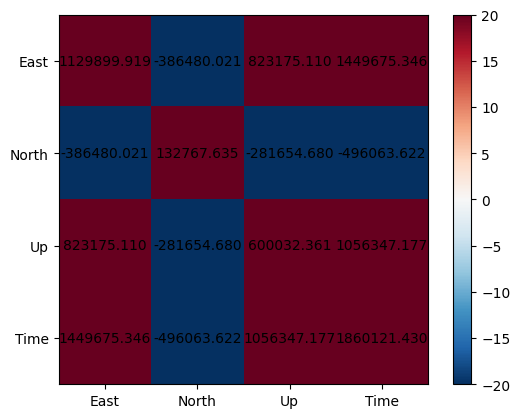

In [ ]:
H_mh = compute_dop_matrix(data_mh_az, data_mh_el, use_degree=True)
plot_dop_matrix(H_mh, vmin=-20, vmax=20)
print(f"PDOP: {compute_pdop(H_mh)}")

PDOP: 1359.584004912472


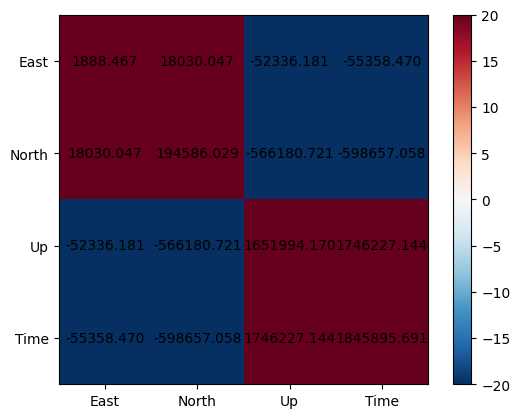

In [ ]:
H_rb = compute_dop_matrix(data_rb_az, data_rb_el, use_degree=True)
plot_dop_matrix(H_rb, vmin=-20, vmax=20)
print(f"PDOP: {compute_pdop(H_rb)}")

PDOP: 1364.5527376552623


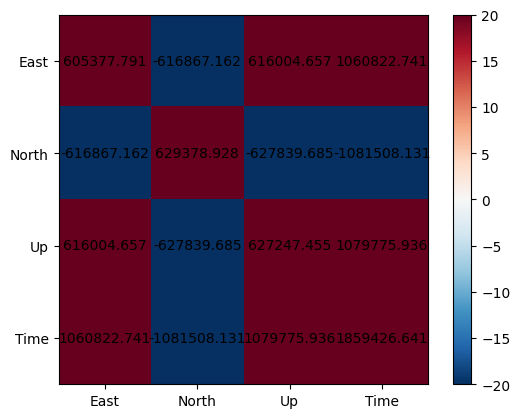

In [ ]:
H_gd = compute_dop_matrix(data_gd_az, data_gd_el, use_degree=True)
plot_dop_matrix(H_gd, vmin=-20, vmax=20)
print(f"PDOP: {compute_pdop(H_gd)}")

They have about the same PDOP, but the locations with a more direct line-of-sight of the Earth have a slightly lower PDOP.

The smallest PDOP is `1359.6` for Rima Bode (with satellites almost directly overhead), and the largest is `1372.1` for Shackleton (with satellites clustered near the horizon).



#### 3.8 Bonus [1 point]
For each of the 4 locations, compute the **Time Dilution of Precision (TDOP)** values. How does it compare with PDOP? (Is it significantly larger, significantly smaller, or nearly the same?) Why do you think this happens?

***ANSWER***

In [ ]:
tdop_sh = np.sqrt(H_sh[3,3])
tdop_mh = np.sqrt(H_mh[3,3])
tdop_rb = np.sqrt(H_rb[3,3])
tdop_gd = np.sqrt(H_gd[3,3])

print(f"TDOP (sh): {tdop_sh}")
print(f"TDOP (mh): {tdop_mh}")
print(f"TDOP (rb): {tdop_rb}")
print(f"TDOP (gd): {tdop_gd}")


TDOP (sh): 1371.200144992796
TDOP (mh): 1363.8626874375789
TDOP (rb): 1358.6374392077305
TDOP (gd): 1363.607949784367


The PDOP and TDOP are nearly the same. Because the satellites are close together in the sky, the vectors between the receiver and each satellite are essentially the same. This causes the rows of the G matrix to be essentially the same, which makes the diagonals about the same. Doing the math for $H$, this causes all diagonals to be about the same as well, which is why the PDOP and TDOP are about the same (both calculated from diagonals of the H matrix).

#### 3.9 Bonus [1 point]
Consider navigating a user at **Shackleton** (which is located near the south pole). If you can add one more navigation satellite (a lunar GPS satellite!) anywhere in the sky to improve the PDOP (at this particular time epoch), where do you think would be a good location to add the new navigation satellite? Why do you think that would be a good location?

You do not have to compute the optimal location, nor compute the new DOP values. Also, You do not have to consider about the feasibility of the orbits.

***ANSWER***

A good location for the satellite would be on a polar with its orbital plane orthogonal to the moon's vector to Earth. Even though it is at low elevation, it would be a good location because there is no atmospheric or physical attenuation on the moon. It would also cause the satellites to be approximately in a line, but it would significantly improve one direction of error.